Exercise 4: NumPy Array Operations

In [36]:
# 5x5 matrix where border elements are 1 and interior is 0
import numpy as np

matrix = np.ones((5, 5))
matrix[1:4, 1:4] = 0

print("5x5 matrix where border elements are 1 and interior is 0")
print(matrix)

5x5 matrix where border elements are 1 and interior is 0
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [7]:
# Normalizing a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)
normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print("Normalized array:")
print(f"Mean of each column:{normalized_data.mean(axis=0).round(4)}")
print(f"Std of each column:{normalized_data.std(axis=0).round(4)}")

Normalized array:
Mean of each column: [-0.  0. -0.]
Std of each column: [1. 1. 1.]


In [37]:
#Implementing linear regression solution using normal equation
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print(f"True theta:{true_theta}")
print(f"Estimated coefficient:{theta_hat.round(4)}")

True theta:[ 2.5 -1.2  3.7]
Estimated coefficient:[ 2.4869 -1.1915  3.6922]


Exercise 5: Pandas Data Analysis

In [39]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [43]:
# Data Cleaning and Exploration
print("Information about dataset:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing exam_score with mean score for the student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))

# Fill missing hours_studied with median for the student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Information about dataset:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             200 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          200 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None

Missing Values:
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: int64

Missing Values After Cleaning:
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype

In [19]:
#Analysis
#Average exam_score by major
average_by_major = df.groupby('major')['exam_score'].mean()
print("Average exam score by major:")
print(average_by_major.round(2))

# Major with highest average exam score
major_hscore = average_by_major.idxmax()
print(f"\nMajor with highest average score:{major_hscore}")

# Correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])
print(f"\nCorrelation between hours studied and exam score:{correlation:.5f}")

# Create performance column
def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)
print("\nPerformance categories:")
print(df['performance'].value_counts())

Average exam score by major:
major
Biology    75.50
CS         76.43
Math       74.68
Physics    75.41
Name: exam_score, dtype: float64

Major with highest average score:CS

Correlation between hours studied and exam score:-0.05598

Performance categories:
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


In [45]:
# Advanced Analysis

# For each major and year combination
group_analysis = df.groupby(['major', 'year']).agg(num_students=('exam_score', 'count'),
avg_exam_score=('exam_score', 'mean'), avg_hours_studied=('hours_studied', 'mean')).round(2)

print("Analysis by Major and Year:")
print(group_analysis)

# Top 5 students based on exam_score
top_5 = df.nlargest(5, 'exam_score')[['student_id', 'major', 'year', 'exam_score']]
print("\nTop 5 Students:")
print(top_5)

# Pivot table
pivot = df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean').round(2)
print("\nPivot Table:")
print(pivot)

Analysis by Major and Year:
              num_students  avg_exam_score  avg_hours_studied
major   year                                                 
Biology 1               13           76.57              12.68
        2               12           74.90              13.43
        3               14           80.18              14.49
        4               15           70.70              14.25
CS      1               12           77.10              13.04
        2                7           76.16              14.00
        3                9           72.35              15.04
        4               18           78.12              16.28
Math    1               11           74.05              19.00
        2                9           81.23              12.35
        3               10           72.02              15.18
        4               16           73.10              17.42
Physics 1               13           77.83              13.49
        2               12           73.28

Exercise 6: Data Visualization

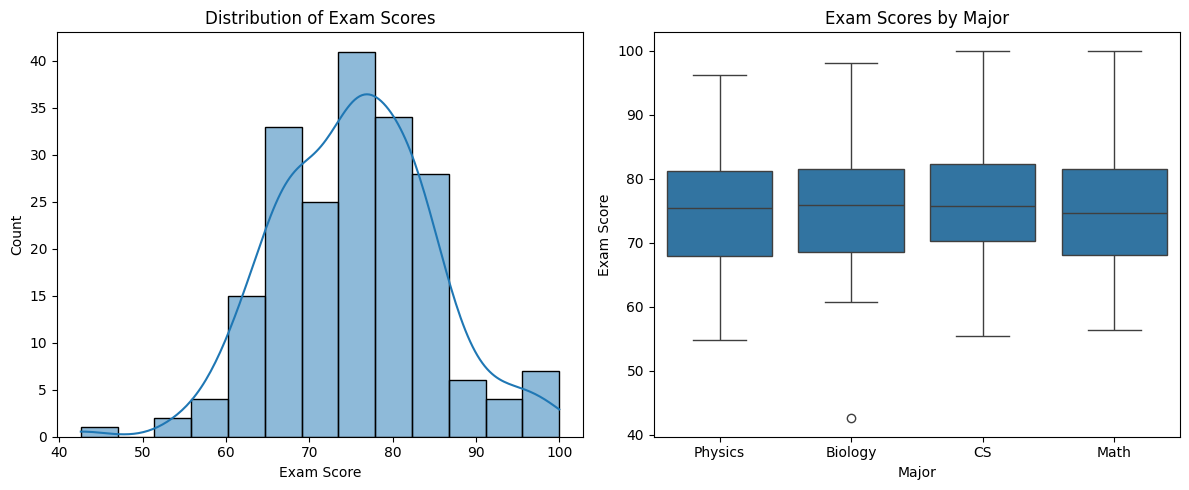

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

#Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Histogram of exam scores with KDE overlay
sns.histplot(data=df, x='exam_score', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')

#Box plot of exam scores by major
sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1])
axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

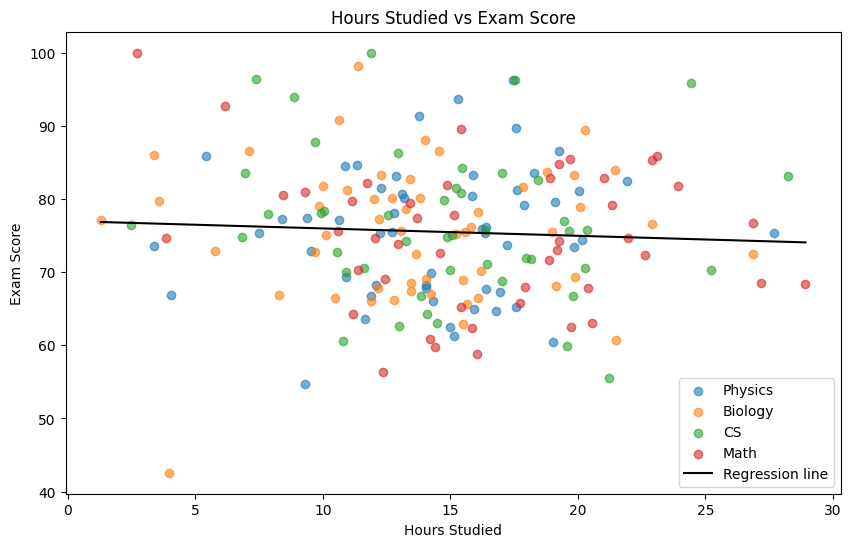

In [50]:
#Relationship Visualization
plt.figure(figsize=(10, 6))
# Scatter plot of hours_studied vs exam_score and yesRegression line
for major in df['major'].unique():
    subset = df[df['major'] == major]
    plt.scatter(subset['hours_studied'], subset['exam_score'], label=major, alpha=0.6)

m, b = np.polyfit(df['hours_studied'], df['exam_score'], 1)
plt.plot(df['hours_studied'].sort_values(), m * df['hours_studied'].sort_values() + b, color='black', label='Regression line')

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

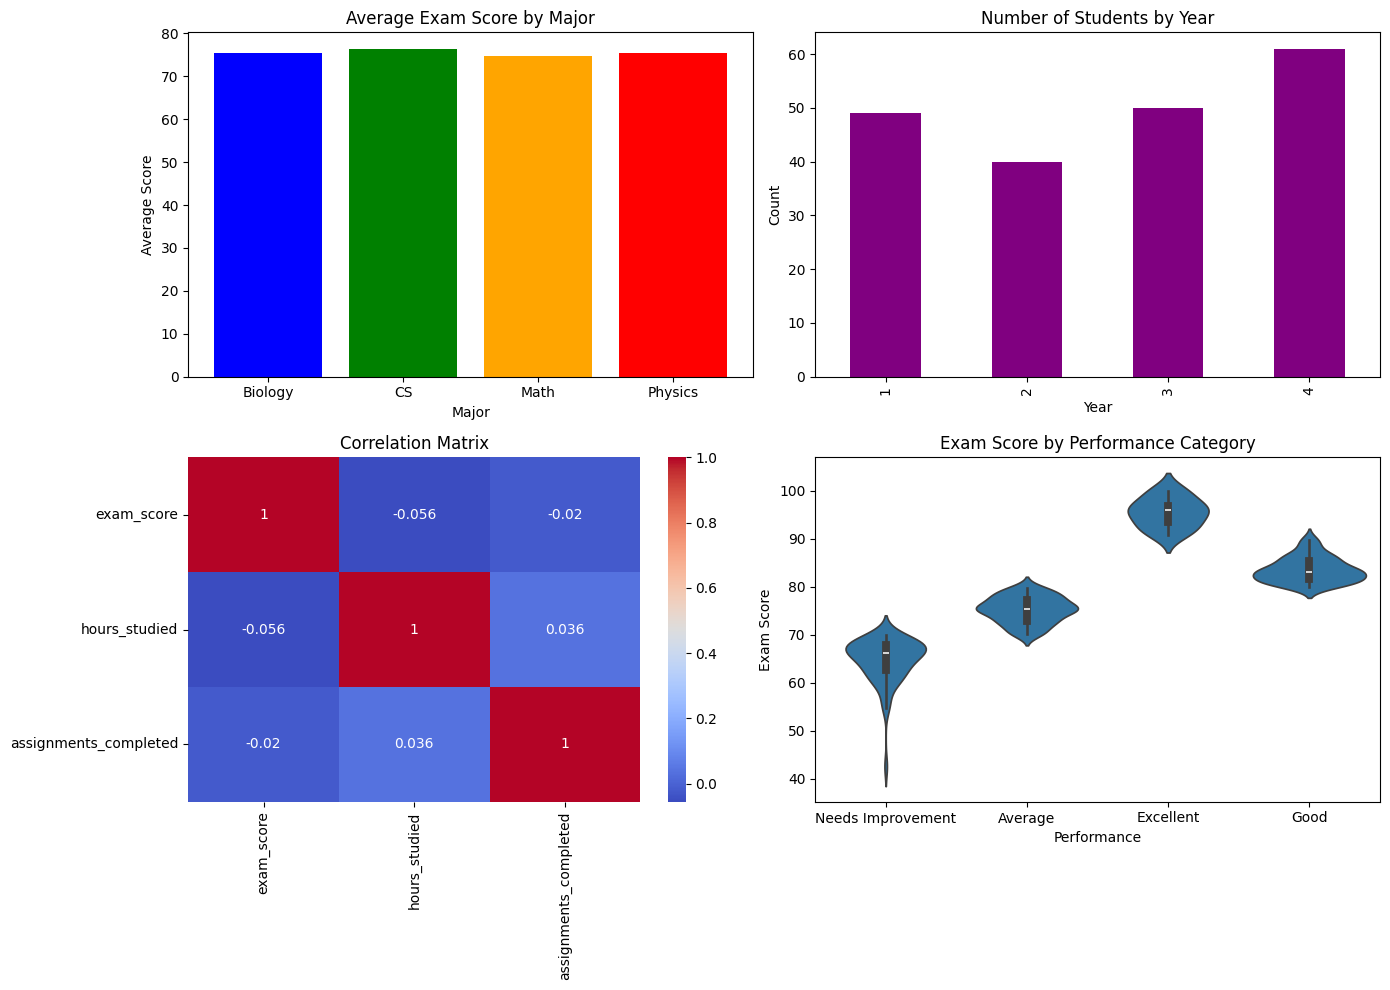

In [29]:
#Advanced Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Bar chart: Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean()
axes[0, 0].bar(avg_scores.index, avg_scores.values, color=['blue', 'green', 'orange', 'red'])
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

# Count plot: Number of students by year
df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='purple')
axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

#Heatmap: Correlation matrix of numerical columns
corr = df[['exam_score', 'hours_studied', 'assignments_completed']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')

# 4. Violin plot: Exam score by performance category
sns.violinplot(data=df, x='performance', y='exam_score', ax=axes[1, 1])
axes[1, 1].set_title('Exam Score by Performance Category')
axes[1, 1].set_xlabel('Performance')
axes[1, 1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

Exercise 7: Integration Challenge

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({'age': ages, 'income': income,'purchase_frequency': purchase_freq, 'avg_purchase_value': avg_purchase_value})

Dataset created successfully!
   age        income  purchase_frequency  avg_purchase_value
0   56  92443.123940                   7           94.527456
1   69  70649.305211                   2          100.932279
2   46  19612.600681                   3           79.699876
3   32  40315.318543                   2          130.137787
4   60  75338.222984                   8          102.904845


In [52]:
# Calculate Customer Lifetime Value (CLV)
max_frequency = customers['purchase_frequency'].max()
churn_risk = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + churn_risk)

print("CLV and age groups")
print(customers[['age', 'age_group', 'CLV']].head())

CLV and age groups
   age age_group          CLV
0   56     51-70   937.397271
1   69     51-70   370.085023
2   46     36-50   418.424348
3   32     26-35   477.171887
4   60     51-70  1097.651683


In [54]:
# Analysis by age group
age_group_analysis = customers.groupby('age_group', observed=True).agg(
    num_customers=('CLV', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).round(2)
print(age_group_analysis)

           num_customers  avg_income  avg_CLV  total_CLV
age_group                                               
18-25                 69    51805.88   704.49   48609.99
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99


In [55]:
# Top 10% customers by CLV
top_10_percent = customers.nlargest(int(len(customers) * 0.1), 'CLV')
print(f"\nTop 10% customers ({len(top_10_percent)} customers):")
print(top_10_percent[['age', 'age_group', 'income', 'CLV']].head())


Top 10% customers (50 customers):
     age age_group        income          CLV
426   42     36-50  68713.567863  1645.711441
213   41     36-50  45580.608009  1635.458860
410   44     36-50  49344.934596  1593.874900
194   44     36-50  57331.964922  1589.765308
244   28     26-35  29255.076913  1584.534373


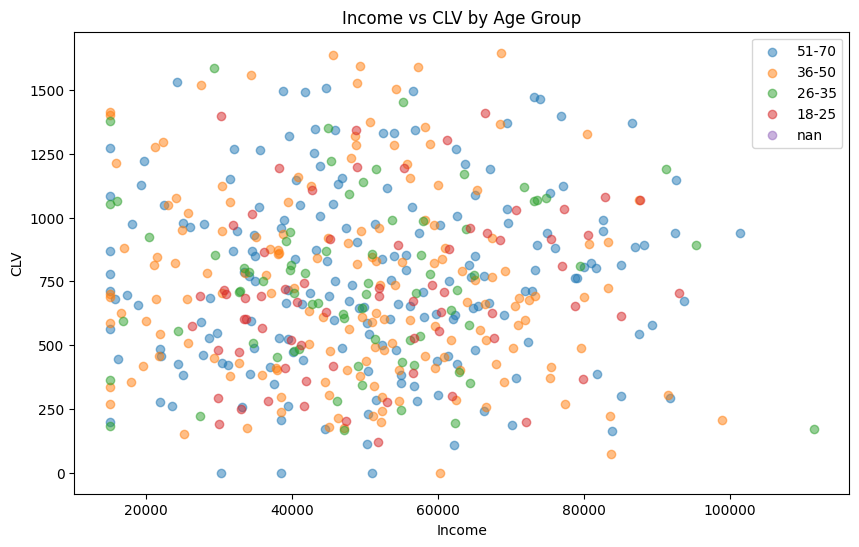

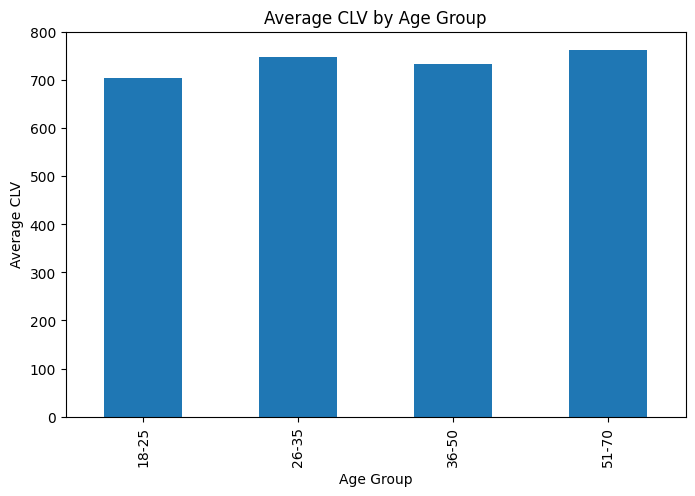

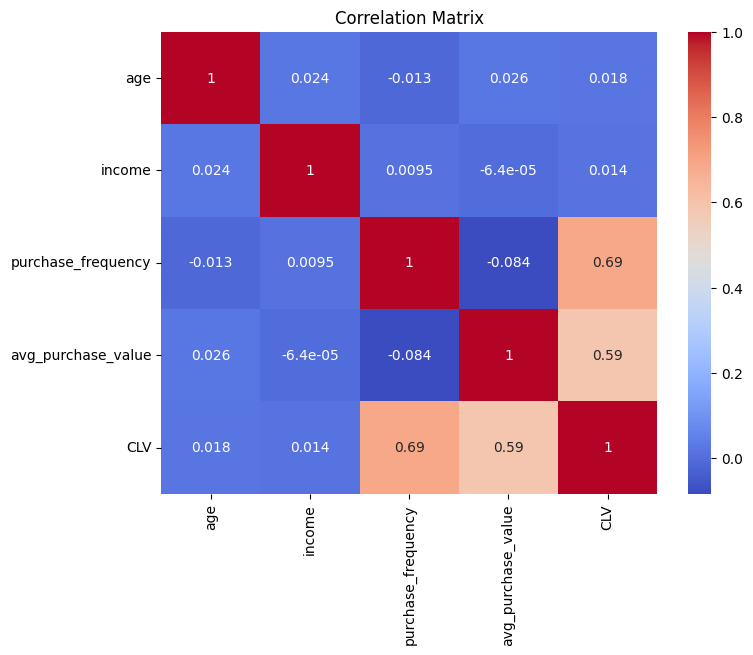

In [56]:
# Visualizations
# 1. Scatter plot of income vs CLV colored by age group
plt.figure(figsize=(10, 6))
for group in customers['age_group'].unique():
    subset = customers[customers['age_group'] == group]
    plt.scatter(subset['income'], subset['CLV'], label=group, alpha=0.5)
plt.title('Income vs CLV by Age Group')
plt.xlabel('Income')
plt.ylabel('CLV')
plt.legend()
plt.show()

# 2. Bar chart of average CLV by age group
plt.figure(figsize=(8, 5))
age_group_analysis['avg_CLV'].plot(kind='bar')
plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(8, 6))
corr = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Key Findings and Recommendations

I found that the customers between age 26 and 35 have the higher average CLV of 747.74 even though it has fewer customers compared to older groups. Also, the age group of 51-70 generates the highest total CLV of 141,860 this group has a highest average CLV of 762.69 which makes them the most valuable customer group.

Another insight is that, based on the correlation heatmap, income is not a strong influencer of CLV but rather purchase frequency and average purchase value have a strong influence on CLV. 

This suggests that the company should focus more on purchase frequency rather than focusing on high income customers. This can be done through targeted promotions and loyalty programs.